# MNIST DIGIT CLASSIFICATION USING CNN

## IMPORT LIBRARIES

In [1]:
import numpy as np # mathematical operations and array handling
import matplotlib.pyplot as plt # plotting images and graphs
import seaborn as sns # better visualization of confusion matrix
from tensorflow.keras.datasets import mnist # dataset loader for MNIST
from tensorflow.keras.models import Sequential # model allows stacking layers one after another
from tensorflow.keras.layers import (
    Input,
    Conv2D,        # Conv2D → feature extraction
    MaxPooling2D,  # MaxPooling2D → dimensionality reduction
    Dropout,       # Dropout → regularization
    Flatten,       # Flatten → convert 2D feature maps into 1D vector
    Dense          # Dense → fully connected classification layers
)
from tensorflow import newaxis # Adds channel dimension to grayscale images
from tensorflow.keras.callbacks import EarlyStopping # prevents overfitting
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics

## LOAD DATASET

- MNIST dataset contains handwritten digits 0–9
- Each image is 28x28 pixels

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## NORMALIZATION
Neural networks perform better when inputs are small and scaled. After normalization: values lie between 0 and 1

`x_normalized = x / 255`

Each image is a matrix of pixel values. Pixel intensity range:
- 0   → black (no light)
- 255 → white (full intensity)

Benefits:
- Faster gradient descent
- More stable learning
- Prevents large weight updates

Example image matrix:
```text
[[0,  50, 255],
[10, 80, 200]]
```

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## RESHAPING FOR CNN

CNN expects input shape: `(height, width, channels)`

- Original shape: (60000, 28, 28)
- New shape: (60000, 28, 28, 1) : Our images are grayscale → 1 channel

In [4]:
X_train = X_train[..., newaxis]
X_test = X_test[..., newaxis]

In [5]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## BUILD CNN MODEL

- **Convolution Layer:** operation extracts local patterns -> `Output(i,j) = Σ (Image × Kernel)`
- **ReLU activation:** `f(x) = max(0, x)`
- **MaxPooling:** reduces image size and computation, it keeps only strongest features and avoids overfitting
- **Dropout:** randomly disables neurons -> `keep probability = 1 - dropout_rate`
  -- Overfitting problem: model memorizes training data
- **Flatten:** converts 2D feature maps → 1D vector
- **Dense:** Fully Connected Layer
    - Neuron formula: `z = w1x1 + w2x2 + ... + wnxn + b`
    - Each neuron combines extracted features
- **Dense:** Output Layer
    - **Softmax** converts outputs into probabilities -> `p(i) = e^(xi) / Σ e^(xj)`
    - Sum of all outputs = 1

In [6]:
model = Sequential([

    Input(shape=(28, 28, 1)),
    Conv2D(
        32,                 # model learns 32 feature detectors
        (3,3),              # scans 3x3 region at a time
        activation="relu"   # Removes negative values and adds non-linearity
    ),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"), # model learns 64 feature detectors
    MaxPooling2D((2,2)),
    Dropout(0.25),          # 25% neurons ignored during training
    Flatten(),
    Dense(128, activation="relu"),  # Fully Connected Layer
    Dense(10, activation="softmax") # Output LAyer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## COMPILE MODEL

**Optimizer:** Adam combines Momentum and Adaptive learning rate
  - Weight update idea: `θ = θ - α * gradient`

**Loss function:** Sparse Categorical Crossentropy
  - `Loss = -log(p_true)` -> where p_true = predicted probability of correct class

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## TRAIN MODEL

- Early stopping prevents overfitting
- Stops training when validation loss stops improving

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9429 - loss: 0.1880 - val_accuracy: 0.9848 - val_loss: 0.0524
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9825 - loss: 0.0575 - val_accuracy: 0.9902 - val_loss: 0.0386
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.9869 - loss: 0.0406 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9894 - loss: 0.0323 - val_accuracy: 0.9908 - val_loss: 0.0329
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9912 - loss: 0.0266 - val_accuracy: 0.9913 - val_loss: 0.0309
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9912 - val_loss: 0.0335
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9941 - loss: 0.0176 - val_accuracy: 0.9913 - val_loss: 0.0342
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9944 - loss: 0.0164 - 

## EVALUATION
- Precision = TP / (TP + FP)
- Recall    = TP / (TP + FN)
- F1 Score  = 2PR / (P + R)

In [10]:
# ACCURACY AND LOSS
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss, 4))
print(f"Test Accuracy: {test_acc:4f} -> {test_acc:2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9917 - loss: 0.0237
Test Loss: 0.0237
Test Accuracy: 0.991700 -> 99.169999%


In [11]:
# PREDICTIONS
y_prob = model.predict(X_test)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [12]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 976,    0,    1,    0,    0,    0,    1,    1,    1,    0],
       [   0, 1132,    0,    0,    0,    0,    3,    0,    0,    0],
       [   0,    1, 1025,    0,    3,    0,    0,    3,    0,    0],
       [   0,    1,    3, 1003,    0,    2,    0,    0,    1,    0],
       [   0,    0,    0,    0,  979,    0,    0,    0,    0,    3],
       [   1,    0,    1,    9,    0,  878,    2,    0,    0,    1],
       [   5,    1,    0,    0,    1,    1,  950,    0,    0,    0],
       [   0,    1,    4,    1,    0,    0,    0, 1021,    0,    1],
       [   2,    0,    2,    1,    0,    0,    1,    0,  967,    1],
       [   2,    2,    1,    2,    4,    2,    0,    6,    4,  986]])

## VISUALIZATIONS

### CONFUSION MATRIX

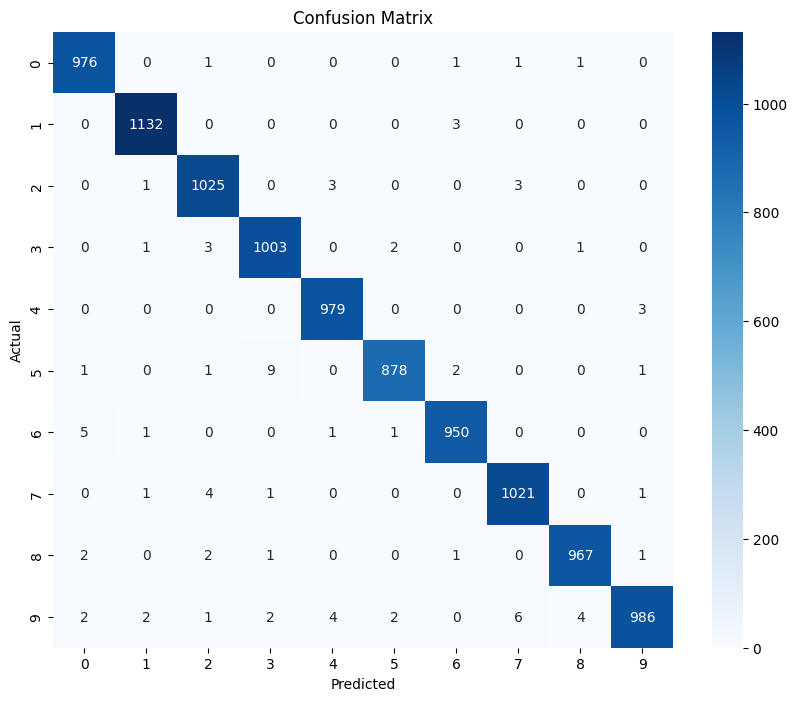

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
    )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### SAMPLE IMAGES

#### BEFORE PREDICTIONS

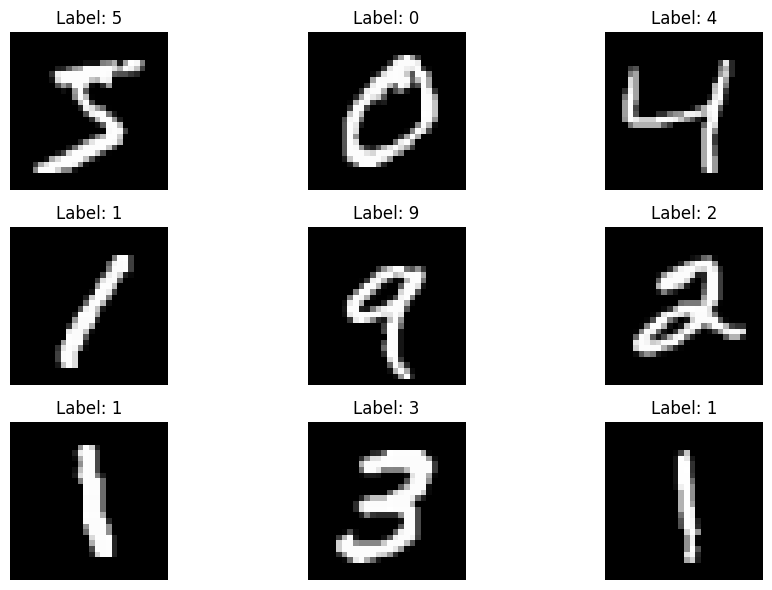

In [17]:
plt.figure(figsize=(10, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

#### AFTER PREDICTIONS

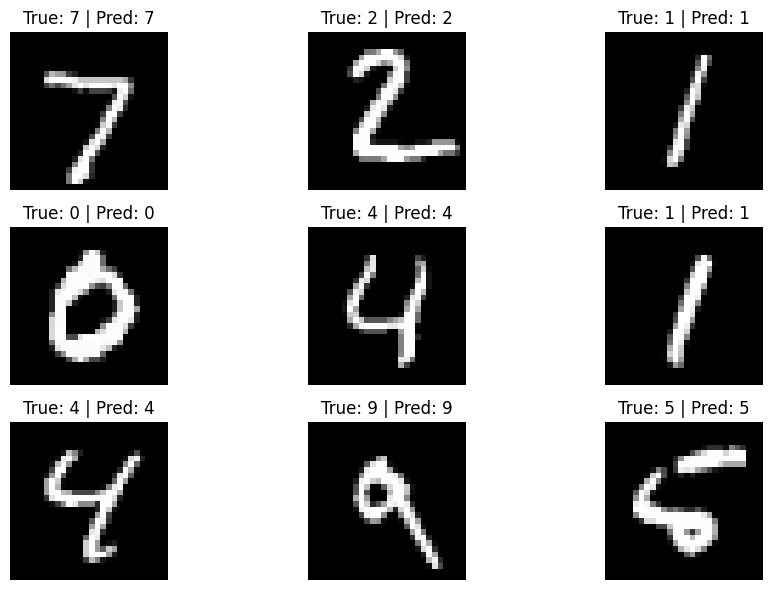

In [21]:
plt.figure(figsize=(10, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"True: {y_test[i]} | Pred: {y_pred[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### TRAINING CURVES

#### Loss Curve

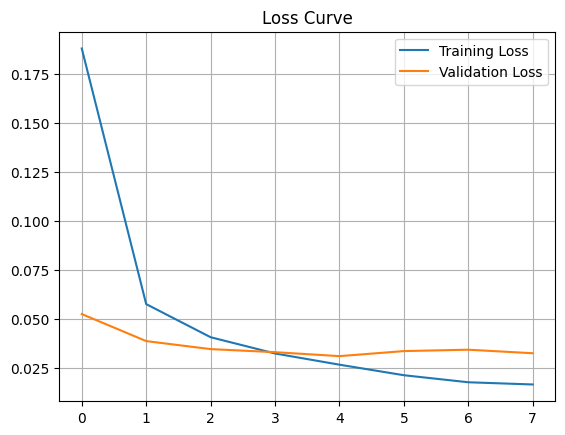

In [19]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

#### Accuracy Curve

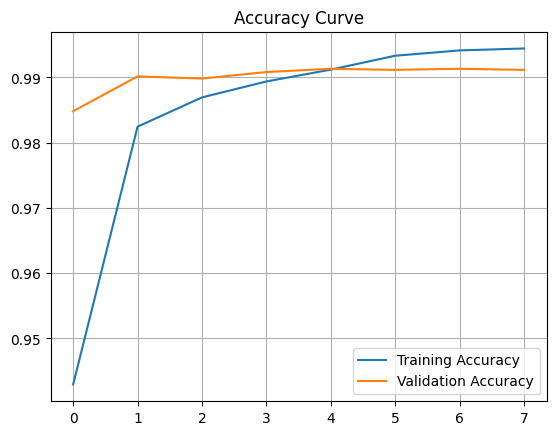

In [20]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

## INSIGHTS

CNN transforms raw pixels → features → classification

**The CNN learns hierarchical patterns:**

1. Early layers → edges and simple shapes
2. Middle layers → object parts
3. Deep layers → full object representation

**Why CNN works well:**

- Convolution reduces parameters
- Weight sharing improves efficiency
- Pooling reduces spatial size
- Softmax outputs probability distribution

**Final conclusion:** Model successfully classifies digitss with high accuracy using learned visual features.